# 08 - Hyperparameter Study
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

Studies how 3 key AC-PINN hyperparameters affect final accuracy on
Burgers' equation under noisy sparse data (same condition as the
ablation study). For each study, AC-PINN (`weight_strategy='both'`) is
trained once per parameter value (all other params left at default),
and the final Rel L2 error vs the FDM ground truth is recorded.

1. **Number of curriculum stages** (`n_stages`) - [2, 4, 6, 8]
2. **Resample frequency** (`resample_every`, fixed-interval mode) - [100, 250, 500, 1000, 2000]
3. **Collocation pool size** (`N_pool`) - [5000, 10000, 20000, 50000]


In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, ACPINNSolver, BurgersFDM, Benchmark,
    save_metrics
)

PDE        = 'burgers'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS    = '../results/burgers/'
FIGURES    = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen  = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
# Same hardest condition as the ablation study - noisy + sparse
data = gen.generate(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1)

fdm  = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
print(f'Device: {device} | Data ready')


BurgersFDM solved in 0.6768s
Device: cuda | Data ready


In [2]:
def rel_l2_error(model, fdm, nx=200, nt=100):
    """Final Rel L2 error of a trained model vs the FDM ground truth."""
    bench = Benchmark(fdm, nx=nx, nt=nt)
    bench.add('model', model)
    bench.run()
    diff = bench.U_preds['model'] - bench.U_fdm
    return float(np.linalg.norm(diff) / (np.linalg.norm(bench.U_fdm) + 1e-10))


def plot_param_study(param_name, values, errors, save_path, xlabel, log_x=False):
    plt.figure(figsize=(7, 5))
    plt.plot(values, errors, 'o-', lw=2, markersize=8)
    if log_x:
        plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel('Final Rel L2 Error')
    plt.title(f'Parameter Study - {param_name}')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


## Study 1 - Number of Curriculum Stages

`CurriculumSampler` now accepts an `n_stages` parameter (previously
hardcoded to 4): the pool-difficulty cutoffs and fixed-epoch fractions
are split equally across `n_stages`, and (in dynamic-curriculum mode)
the residual-based `stage_thresholds` are auto-generated as a
decreasing sequence from 0.5 to 0.05 with `n_stages - 1` entries.

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[ParamStudy | n_stages=2 | Epoch     0/10000] Stage 1/2 | Total: 1.092126 | IC: 0.811687 | BC: 0.191727 | PDE: 0.017742 | lam=(1.00,1.00,5.00)


[ParamStudy | n_stages=2 | Epoch  2000/10000] Stage 1/2 | Total: 0.071380 | IC: 0.008655 | BC: 0.020283 | PDE: 0.000539 | lam=(4.52,1.32,10.00)


[ParamStudy | n_stages=2 | Epoch  4000/10000] Stage 1/2 | Total: 0.043335 | IC: 0.007688 | BC: 0.010210 | PDE: 0.000153 | lam=(3.44,1.50,10.00)


[ParamStudy | n_stages=2 | Epoch  6000/10000] Stage 2/2 | Total: 0.212497 | IC: 0.008123 | BC: 0.003746 | PDE: 0.084141 | lam=(9.42,10.00,1.17)


...

[ParamStudy | n_stages=8 | Epoch  2000/10000] Stage 2/8 | Total: 0.068560 | IC: 0.018327 | BC: 0.007382 | PDE: 0.001194 | lam=(1.59,4.03,8.02)


[ParamStudy | n_stages=8 | Epoch  4000/10000] Stage 4/8 | Total: 0.022504 | IC: 0.008942 | BC: 0.006062 | PDE: 0.000602 | lam=(1.72,1.17,0.12)


[ParamStudy | n_stages=8 | Epoch  6000/10000] Stage 5/8 | Total: 0.014172 | IC: 0.006307 | BC: 0.002722 | PDE: 0.001339 | lam=(1.82,0.79,0.39)


[ParamStudy | n_stages=8 | Epoch  8000/10000] Stage 7/8 | Total: 0.021526 | IC: 0.007009 | BC: 0.003768 | PDE: 0.008772 | lam=(1.08,0.58,1.35)



AC-PINN training complete in 155.75s
n_stages=8 -> Rel L2 = 0.383926


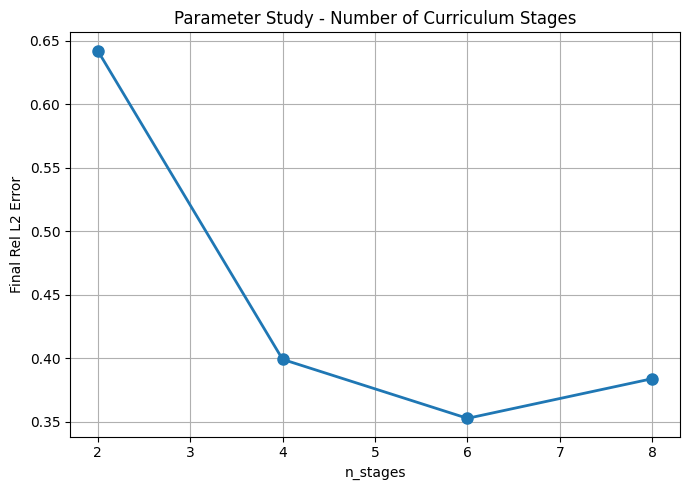

Saved: ../figures/burgers/param_study_n_stages.png


In [3]:
stage_values = [2, 4, 6, 8]
stage_errors = []
stage_histories = {}

for n_stages in stage_values:
    m = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                      weight_strategy='both', n_stages=n_stages)
    h = m.fit(data, epochs=EPOCHS, print_every=2000,
              label=f'ParamStudy | n_stages={n_stages}')
    err = rel_l2_error(m, fdm)
    stage_errors.append(err)
    stage_histories[n_stages] = h
    print(f'n_stages={n_stages} -> Rel L2 = {err:.6f}')

plot_param_study('Number of Curriculum Stages', stage_values, stage_errors,
                  FIGURES + 'param_study_n_stages.png', xlabel='n_stages')


## Study 2 - Resample Frequency

Uses the existing `resample_every` parameter with `adaptive_resample=False`
(fixed-interval resampling, matching the original scheduling behavior).

[ParamStudy | resample_every=100 | Epoch     0/10000] Stage 1/4 | Total: 1.171395 | IC: 0.879045 | BC: 0.252494 | PDE: 0.007971 | lam=(1.00,1.00,5.00)


[ParamStudy | resample_every=100 | Epoch  2000/10000] Stage 1/4 | Total: 0.038496 | IC: 0.011480 | BC: 0.005911 | PDE: 0.000247 | lam=(1.56,3.06,10.00)


[ParamStudy | resample_every=100 | Epoch  4000/10000] Stage 2/4 | Total: 0.025447 | IC: 0.006428 | BC: 0.004649 | PDE: 0.000102 | lam=(2.40,1.94,10.00)


[ParamStudy | resample_every=100 | Epoch  6000/10000] Stage 3/4 | Total: 0.012602 | IC: 0.005500 | BC: 0.003368 | PDE: 0.001830 | lam=(1.54,0.94,0.51)


[ParamStudy | resample_every=100 | Epoch  8000/10000] Stage 4/4 | Total: 0.402794 | IC: 0.008221 | BC: 0.008827 | PDE: 0.148681 | lam=(0.15,0.16,2.69)


...

[ParamStudy | resample_every=2000 | Epoch  2000/10000] Stage 1/4 | Total: 0.065793 | IC: 0.019111 | BC: 0.004039 | PDE: 0.000232 | lam=(1.21,10.00,10.00)


[ParamStudy | resample_every=2000 | Epoch  4000/10000] Stage 2/4 | Total: 0.052406 | IC: 0.016558 | BC: 0.002862 | PDE: 0.000408 | lam=(1.23,10.00,8.39)


[ParamStudy | resample_every=2000 | Epoch  6000/10000] Stage 3/4 | Total: 0.026099 | IC: 0.011280 | BC: 0.003788 | PDE: 0.001447 | lam=(2.05,0.69,0.26)


[ParamStudy | resample_every=2000 | Epoch  8000/10000] Stage 4/4 | Total: 0.104319 | IC: 0.025743 | BC: 0.016598 | PDE: 0.046307 | lam=(0.87,0.56,1.57)



AC-PINN training complete in 146.98s
resample_every=2000 -> Rel L2 = 0.382903


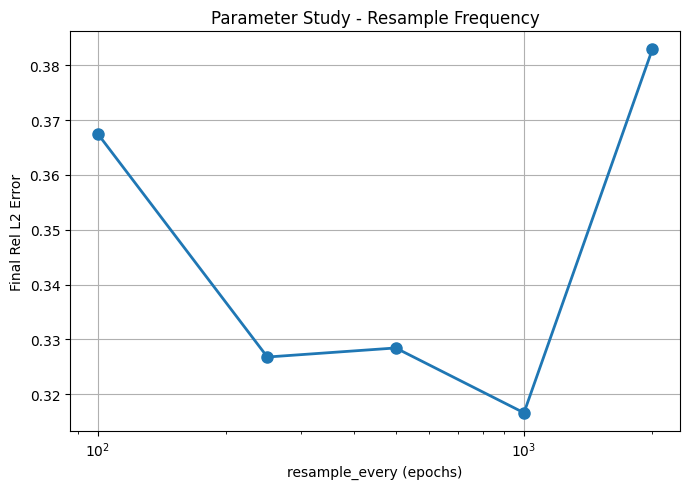

Saved: ../figures/burgers/param_study_resample_every.png


In [4]:
resample_values = [100, 250, 500, 1000, 2000]
resample_errors = []
resample_histories = {}

for resample_every in resample_values:
    m = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                      weight_strategy='both', resample_every=resample_every)
    h = m.fit(data, epochs=EPOCHS, print_every=2000,
              adaptive_resample=False,
              label=f'ParamStudy | resample_every={resample_every}')
    err = rel_l2_error(m, fdm)
    resample_errors.append(err)
    resample_histories[resample_every] = h
    print(f'resample_every={resample_every} -> Rel L2 = {err:.6f}')

plot_param_study('Resample Frequency', resample_values, resample_errors,
                  FIGURES + 'param_study_resample_every.png',
                  xlabel='resample_every (epochs)', log_x=True)


## Study 3 - Collocation Pool Size

[ParamStudy | N_pool=5000 | Epoch     0/10000] Stage 1/4 | Total: 0.503918 | IC: 0.384653 | BC: 0.103875 | PDE: 0.003078 | lam=(1.00,1.00,5.00)


[ParamStudy | N_pool=5000 | Epoch  2000/10000] Stage 1/4 | Total: 0.063318 | IC: 0.007343 | BC: 0.012871 | PDE: 0.000050 | lam=(6.42,1.22,10.00)


[ParamStudy | N_pool=5000 | Epoch  4000/10000] Stage 2/4 | Total: 0.074261 | IC: 0.006402 | BC: 0.014080 | PDE: 0.000026 | lam=(9.02,1.15,10.00)


[ParamStudy | N_pool=5000 | Epoch  6000/10000] Stage 3/4 | Total: 0.014626 | IC: 0.006023 | BC: 0.004658 | PDE: 0.002640 | lam=(1.36,1.05,0.59)


[ParamStudy | N_pool=5000 | Epoch  8000/10000] Stage 4/4 | Total: 0.481127 | IC: 0.009053 | BC: 0.021030 | PDE: 0.183776 | lam=(0.13,0.30,2.58)


...

[ParamStudy | N_pool=50000 | Epoch  2000/10000] Stage 1/4 | Total: 0.039257 | IC: 0.007056 | BC: 0.008676 | PDE: 0.000126 | lam=(3.14,1.88,6.76)


[ParamStudy | N_pool=50000 | Epoch  4000/10000] Stage 2/4 | Total: 0.025447 | IC: 0.005635 | BC: 0.002885 | PDE: 0.000114 | lam=(3.46,1.82,6.25)


[ParamStudy | N_pool=50000 | Epoch  6000/10000] Stage 3/4 | Total: 0.012045 | IC: 0.005401 | BC: 0.002692 | PDE: 0.002337 | lam=(1.55,0.77,0.67)


[ParamStudy | N_pool=50000 | Epoch  8000/10000] Stage 4/4 | Total: 0.450322 | IC: 0.007070 | BC: 0.006819 | PDE: 0.162354 | lam=(0.12,0.12,2.76)



AC-PINN training complete in 163.32s
N_pool=50000 -> Rel L2 = 0.339937


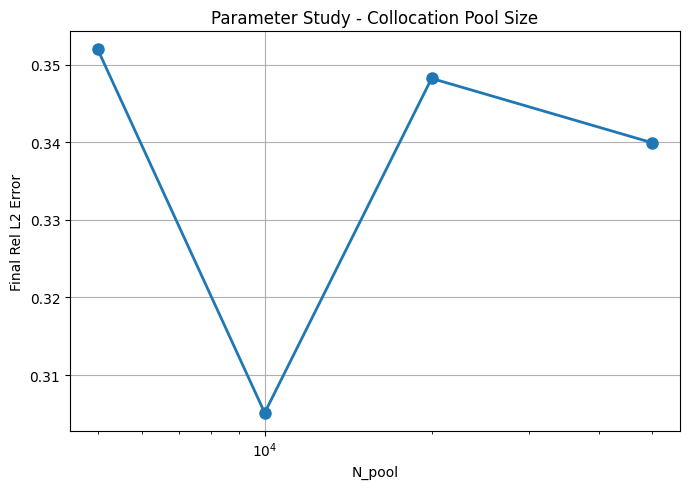

Saved: ../figures/burgers/param_study_N_pool.png


In [5]:
pool_values = [5000, 10000, 20000, 50000]
pool_errors = []
pool_histories = {}

for N_pool in pool_values:
    m = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                      weight_strategy='both', N_pool=N_pool)
    h = m.fit(data, epochs=EPOCHS, print_every=2000,
              label=f'ParamStudy | N_pool={N_pool}')
    err = rel_l2_error(m, fdm)
    pool_errors.append(err)
    pool_histories[N_pool] = h
    print(f'N_pool={N_pool} -> Rel L2 = {err:.6f}')

plot_param_study('Collocation Pool Size', pool_values, pool_errors,
                  FIGURES + 'param_study_N_pool.png',
                  xlabel='N_pool', log_x=True)


## Summary

In [6]:
param_study_results = {
    'n_stages':        dict(zip(stage_values, stage_errors)),
    'resample_every':  dict(zip(resample_values, resample_errors)),
    'N_pool':          dict(zip(pool_values, pool_errors)),
}
save_metrics(param_study_results, RESULTS + 'param_study_metrics.npy')

for study, results in param_study_results.items():
    print(f'\n{study}:')
    for value, err in results.items():
        print(f'  {value:>8} -> Rel L2 = {err:.6f}')

print('\nParameter study complete.')


Saved: ../results/burgers/param_study_metrics.npy

n_stages:
         2 -> Rel L2 = 0.641972
         4 -> Rel L2 = 0.399122
         6 -> Rel L2 = 0.352718
         8 -> Rel L2 = 0.383926

resample_every:
       100 -> Rel L2 = 0.367522
       250 -> Rel L2 = 0.326780
       500 -> Rel L2 = 0.328435
      1000 -> Rel L2 = 0.316598
      2000 -> Rel L2 = 0.382903

N_pool:
      5000 -> Rel L2 = 0.351962
     10000 -> Rel L2 = 0.305127
     20000 -> Rel L2 = 0.348239
     50000 -> Rel L2 = 0.339937

Parameter study complete.
